In [1]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
pin_memory = device.type == "cuda"
print(f"Using device: {device}")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

if device.type == "cuda":
    # Speed up convolutions for fixed-size inputs
    torch.backends.cudnn.benchmark = True

Using device: cuda


In [2]:
from datasets import load_dataset
from datasets import Image

ds = load_dataset("Sandesh-Lav/potato-tuber-caption-dataset")
ds = ds.cast_column("image", Image())

README.md:   0%|          | 0.00/596 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/366M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/360M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/358M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/56.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/66.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1661 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/92 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/93 [00:00<?, ? examples/s]

## Configuration

In [24]:
# --- Configuration ---
MODEL_NAME = "Salesforce/blip-image-captioning-base"

EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 5e-5
MAX_LENGTH = 32
NUM_WORKERS = 1
PREFETCH_FACTOR = 2

SEED = 42

## Load Data & Processor

In [25]:
# Load BLIP processor
#it is used to preprocess the images and captions for the BLIP model.
# It handles tasks like resizing, normalization, and tokenization, ensuring that the inputs are
# in the correct format for the model.
processor = BlipProcessor.from_pretrained(MODEL_NAME)
print("Processor loaded.")

Processor loaded.


## Train/Validation Split & DataLoaders

In [26]:
train_ds = ds["train"]
val_ds = ds["validation"]
test_ds = ds["test"]
print(train_ds[0])

{'image': <PIL.Image.Image image mode=RGB size=1522x1144 at 0x7E36CB5CDA30>, 'caption': 'A whole potato tuber showing severe external manifestation of bacterial soft rot with extensive tissue degradation.'}


In [27]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

def tokenize_captions(batch):
    tokenized = processor.tokenizer(
        batch["caption"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    labels = []
    for ids in tokenized["input_ids"]:
        labels.append([
            token if token != processor.tokenizer.pad_token_id else -100
            for token in ids
        ])

    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        "labels": labels
    }

In [28]:
from torchvision.transforms import InterpolationMode
print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")
print(f"Test samples:  {len(test_ds)}")

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": pin_memory,
}

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

print(
    f"DataLoader config | num_workers={NUM_WORKERS} | "
    f"pin_memory={pin_memory} | persistent_workers={loader_kwargs.get('persistent_workers', False)}"
)

train_ds = train_ds.map(tokenize_captions, batched=True)
val_ds = val_ds.map(tokenize_captions, batched=True)
test_ds = test_ds.map(tokenize_captions, batched=True)

train_ds = train_ds.remove_columns(["caption"])
val_ds = val_ds.remove_columns(["caption"])
test_ds = test_ds.remove_columns(["caption"])


def transform_example(example):
    images = [img.convert("RGB") for img in example["image"]]

    pixel_values = processor.image_processor(
        images=images,
        return_tensors="pt"
    )["pixel_values"]

    return {
        "pixel_values": pixel_values,
        "input_ids": torch.tensor(example["input_ids"]),
        "attention_mask": torch.tensor(example["attention_mask"]),
        "labels": torch.tensor(example["labels"]),
    }

train_ds.set_transform(transform_example)
val_ds.set_transform(transform_example)
test_ds.set_transform(transform_example)

Train samples: 1661
Val samples:   92
Test samples:  93
DataLoader config | num_workers=1 | pin_memory=True | persistent_workers=True


In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

In [30]:
for batch in train_loader:
    print(batch.keys())
    break

dict_keys(['pixel_values', 'input_ids', 'attention_mask', 'labels'])


## Load Model

In [31]:
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(device)
model = model.to(memory_format=torch.channels_last)
#trying gradient checkpointing to fit larger effective batch size on GPU
# model.gradient_checkpointing_enable()
model.config.use_cache = False
# Freeze vision encoder to save memory & speed up training (only train text decoder)
for param in model.vision_model.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Trainable parameters: 161,354,104 / 247,444,600 (65.2%)


## Training Loop

In [32]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(params, lr=LEARNING_RATE)
scaler = GradScaler("cuda", enabled=use_amp)
model.config.use_cache = False

train_losses = []
val_losses = []

# trying gradient accumulation to fit larger effective batch size on GPU
accum_steps = 4
model.config.use_cache = False
model.config.output_attentions = False
model.config.output_hidden_states = False
autocast_ctx = torch.autocast(device_type="cuda", dtype=torch.float16)
# disable vision gradients
model.vision_model.eval()

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    optimizer.zero_grad(set_to_none=True)
    for batch_idx, batch in enumerate(train_loader):
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        pixel_values = batch["pixel_values"].to(
            device, memory_format=torch.channels_last, non_blocking=pin_memory
        )
        input_ids = batch["input_ids"].to(device, non_blocking=pin_memory)
        labels = batch["labels"].to(device, non_blocking=pin_memory)

        # optimizer.zero_grad(set_to_none=True)

        with autocast_ctx:
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                labels=labels,
                attention_mask=attention_mask,
            )
            loss = outputs.loss / accum_steps

        scaler.scale(loss).backward()
        if (batch_idx + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()

        epoch_train_loss += loss.detach()

        if (batch_idx + 1) % 10 == 0:
            print(
                f"  Epoch {epoch+1}/{EPOCHS} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}"
            )
    #step for batches not divisible by accum_steps
    if len(train_loader) % accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    avg_train_loss = epoch_train_loss.item() / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    epoch_val_loss = 0.0

    with torch.inference_mode():
        for batch in val_loader:
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            pixel_values = batch["pixel_values"].to(
                device, memory_format=torch.channels_last, non_blocking=pin_memory
            )
            input_ids = batch["input_ids"].to(device, non_blocking=pin_memory)
            labels = batch["labels"].to(device, non_blocking=pin_memory)

            with autocast_ctx:
                outputs = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    labels=labels,
                    attention_mask=attention_mask,
                )
            epoch_val_loss += outputs.loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
    )

model.config.use_cache = True
print("\nTraining complete!")

  Epoch 1/5 | Batch 10/52 | Loss: 0.6895
  Epoch 1/5 | Batch 20/52 | Loss: 0.4189
  Epoch 1/5 | Batch 30/52 | Loss: 0.3641
  Epoch 1/5 | Batch 40/52 | Loss: 0.3385
  Epoch 1/5 | Batch 50/52 | Loss: 0.2501
Epoch 1/5 — Train Loss: 0.4935 | Val Loss: 0.9083
  Epoch 2/5 | Batch 10/52 | Loss: 0.1919
  Epoch 2/5 | Batch 20/52 | Loss: 0.1872
  Epoch 2/5 | Batch 30/52 | Loss: 0.1591
  Epoch 2/5 | Batch 40/52 | Loss: 0.1590
  Epoch 2/5 | Batch 50/52 | Loss: 0.1375
Epoch 2/5 — Train Loss: 0.1722 | Val Loss: 0.5523
  Epoch 3/5 | Batch 10/52 | Loss: 0.1350
  Epoch 3/5 | Batch 20/52 | Loss: 0.1177
  Epoch 3/5 | Batch 30/52 | Loss: 0.1102
  Epoch 3/5 | Batch 40/52 | Loss: 0.1126
  Epoch 3/5 | Batch 50/52 | Loss: 0.0988
Epoch 3/5 — Train Loss: 0.1173 | Val Loss: 0.4006
  Epoch 4/5 | Batch 10/52 | Loss: 0.0974
  Epoch 4/5 | Batch 20/52 | Loss: 0.0881
  Epoch 4/5 | Batch 30/52 | Loss: 0.0800
  Epoch 4/5 | Batch 40/52 | Loss: 0.0758
  Epoch 4/5 | Batch 50/52 | Loss: 0.0765
Epoch 4/5 — Train Loss: 0.0846

## Loss Curves

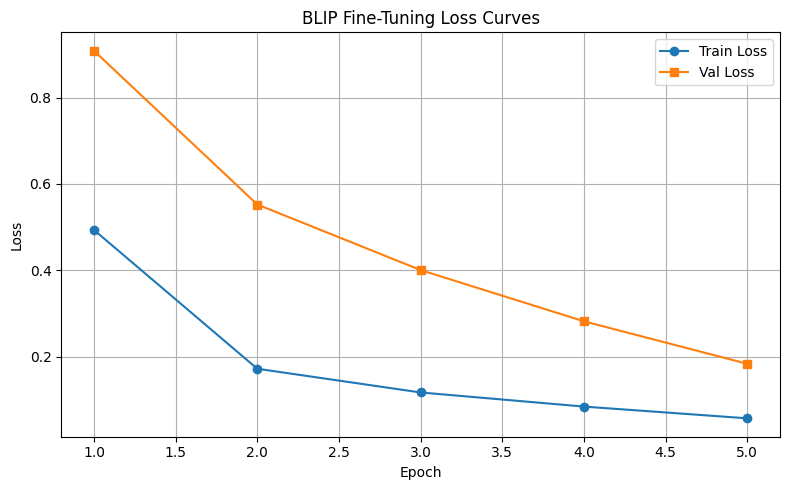

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BLIP Fine-Tuning Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
!pip install pycocoevalcap evaluate rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=6bd2d86db727ab6ee43ab0b3d9e8cb9ecf7efebb1ed2d62e6c8c5d614cae7b90
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [38]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from pycocoevalcap.cider.cider import Cider
import nltk
import evaluate

try:

    nltk.data.find("tokenizers/punkt")

except LookupError:

    nltk.download("punkt")

In [39]:
# Load standardized Hugging Face metrics
bleu_metric = evaluate.load("bleu")
meteor_metric = evaluate.load("meteor")
rouge_metric = evaluate.load("rouge")

# Initialize CIDEr
cider_scorer = Cider()

model.eval()

predictions = []
references = []
gts = {}
res = {}

idx = 0  # Global index for CIDEr formatting

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id

        # Generate captions
        generated_ids = model.generate(
            pixel_values=pixel_values,
            max_new_tokens=32,
            num_beams=4,
        )

        # Decode predictions and references
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
        refs = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)

        # Process and format outputs in a single pass
        for pred, ref in zip(preds, refs):
            clean_pred = pred.strip()
            clean_ref = ref.strip()

            predictions.append(clean_pred)
            references.append(clean_ref)

            # Format dictionaries for CIDEr directly
            res[idx] = [clean_pred]
            gts[idx] = [clean_ref]
            idx += 1

# Compute standard metrics
bleu_result = bleu_metric.compute(predictions=predictions, references=[[ref] for ref in references])
meteor_result = meteor_metric.compute(predictions=predictions, references=references)
rouge_result = rouge_metric.compute(predictions=predictions, references=references)
cider_score, _ = cider_scorer.compute_score(gts, res)

# Print validation results
print("Validation Caption Metrics")
print(f"BLEU: {bleu_result['bleu']:.4f}")
print(f"METEOR: {meteor_result['meteor']:.4f}")
print(f"CIDEr: {cider_score:.4f}")
print(f"ROUGE-L: {rouge_result['rougeL']:.4f}")

# Store results in DataFrame
results_df = pd.DataFrame(
    {
        "reference": references,
        "prediction": predictions,
    }
)

results_df.head(10)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Validation Caption Metrics
BLEU (corpus): 0.8035
BLEU (evaluate): 0.8035
METEOR: 0.8978
CIDEr: 6.6240
ROUGE-L: 0.8879


,reference,prediction
0,a cut - section of a potato tuber showing mode...,a cut - section of a potato tuber showing seve...
1,a whole potato tuber exhibiting normal physiol...,a whole potato tuber exhibiting normal physiol...
2,a whole potato tuber showing mild soft rot sym...,a whole potato tuber showing moderate potato t...
3,a cut - section of a potato tuber showing mild...,a cut - section of a potato tuber showing mild...
4,a cut - section of a potato tuber showing mode...,a cut - section of a potato tuber showing mode...
5,a cut - section of a potato tuber showing mild...,a cut - section of a potato tuber showing mild...
6,a whole potato tuber exhibiting normal physiol...,a whole potato tuber exhibiting normal physiol...
7,a whole potato tuber showing mild soft rot sym...,a whole potato tuber showing moderate potato t...
8,a whole potato tuber showing severe common sca...,a whole potato tuber showing severe common sca...
9,a whole potato tuber showing moderate soft rot...,a whole potato tuber showing severe external m...


## Save Fine-Tuned Model

In [41]:
model.save_pretrained()
processor.save_pretrained()
print(f"Model and processor saved.")

TypeError: PreTrainedModel.save_pretrained() missing 1 required positional argument: 'save_directory'

In [ ]:
from transformers import BlipForConditionalGeneration, BlipProcessor
OUTPUT_DIR = "blip_finetuned"
model = BlipForConditionalGeneration.from_pretrained(OUTPUT_DIR)
processor = BlipProcessor.from_pretrained(OUTPUT_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

## Inference — Generate Captions on Sample Images

In [ ]:
# Load fine-tuned model for inference
model_ft = BlipForConditionalGeneration.from_pretrained(OUTPUT_DIR).to(device)
processor_ft = BlipProcessor.from_pretrained(OUTPUT_DIR)
model_ft.eval()

# Pick random samples from validation set
import random
random.seed(SEED)
sample_indices = random.sample(range(len(val_dataset)), min(6, len(val_dataset)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    sample = val_dataset[idx]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

    # Generate caption
    with torch.no_grad():
        generated_ids = model_ft.generate(pixel_values=pixel_values, max_length=MAX_LENGTH)
    generated_caption = processor_ft.decode(generated_ids[0], skip_special_tokens=True)

    # Get ground truth caption
    original_idx = val_dataset.indices[idx]
    gt_caption = df.iloc[original_idx]["caption"]
    image_path = df.iloc[original_idx]["image_path"]

    # Display
    img = Image.open(image_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(f"GT: {gt_caption[:60]}...\nPred: {generated_caption[:60]}...", fontsize=8, wrap=True)
    axes[i].axis("off")

plt.tight_layout()
plt.show()